# 12 · After the merge: qutrit RB with corrected pulses (2025) and the single-experiment error calibration, DRAPE (2025–26)

When the three repositories were merged (notebooks 01–11) the story stopped in Feb 2025. An archive folder found later
(`archived/`, Oct 2026) holds what came next, on the same `ibm_brisbane` qubit 109 with the same 20 ns pulses:

* **`unifiedPPS`** (2025) — the consolidated analysis for the paper: the amplified-amplitude-error (AAE), amplified-phase-error
  (APE) and DRAG+APE (DRAPE) data reduced to small `.npz` files, the paper figures, the Lindblad fits of $T_1$ and Ramsey,
  and a **new qutrit randomized benchmarking** run with the uncorrected and the corrected $\pi/2$ pulses (`data/paper_2025/`).
* **`qutrit-error`** (Oct 2025 – Jan 2026) — the theory and QuTiP analysis behind the note *Resolving single-qubit gate amplitude
  and phase errors in a single experiment* (`docs/drape_paper_notes_2026-01.pdf`): the drive strengths $\lambda_j$ of the
  transmon ladder, five-level pulse simulations of AAE/APE/DRAPE, and the closed-form DRAPE expression (`data/qutrit_error_2026/`).
* three more Ramsey jobs of 28 Jan 2025 (`data/pending_2025/characterization/ramsey/`, raw shots in the `v1.0-data` release, part 2),
  the bachelor thesis (May 2024) and the 2023 QOC-group material (`docs/`, `data/qoc_2023/`, `literature/`).

This notebook walks through that material with `pulseshop`. The original notebooks are in `misc/original_notebooks/unified_2025/`
and `misc/original_notebooks/qutrit_error_2026/`; the index of every file is in `data/README.md`.

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, curve_fit
from pulseshop import fitting, io, qutrit as Q, simulation as sim, constants as C
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
P = "paper_2025"; QE = "qutrit_error_2026"

## 1. The drive strengths λ₀, λ₁, λ₂ of the transmon ladder

The same microwave amplitude drives the 0–1, 1–2 and 2–3 transitions with different matrix elements. In the drive-frame model of
notebook 10 they enter as $H_j = \tfrac{\lambda_j}{2}\,\Omega(t)\,|j{+}1\rangle\langle j| + \mathrm{h.c.}$, and for a harmonic
ladder $\lambda_j \propto \sqrt{j+1}$. In Oct 2025 three Rabi oscillations were measured on q109 — on 0–1, on 1–2 (with an
active reset of |2⟩ before the sequence) and on 2–3 (reading |3⟩ out through a $\pi_{12}\pi_{01}$ swap, Peterer 2015) — and
the $\lambda_j$ were fitted by overlaying QuTiP simulations (`extract_lambdas.ipynb`). The fitted values are stored in
`lambda_values.npz` and in `constants.LAMBDAS_BRISBANE_Q109`.

lambda_0, lambda_1, lambda_2 = [0.526 0.621 0.753]  ratios to lambda_0: [1.    1.181 1.432]  harmonic-ladder ratios: 1, 1.414, 1.732


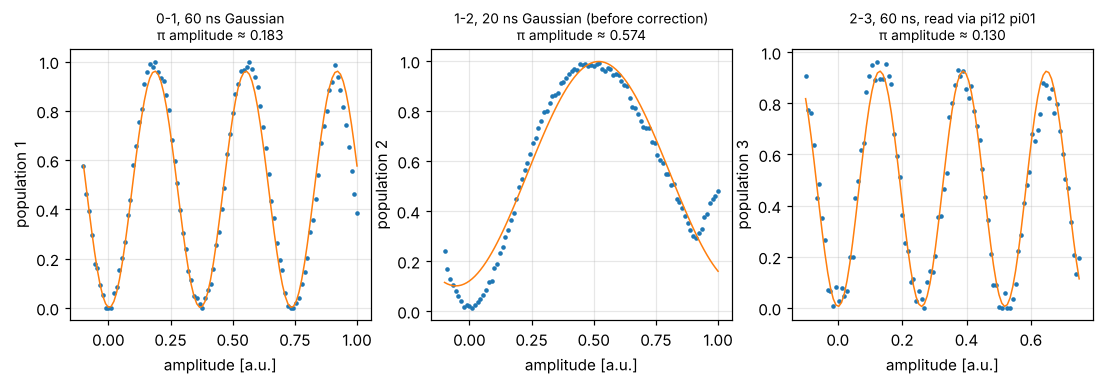

In [2]:
lambdas = np.load(io.data_path(QE, "rabi_osc", "lambda_values.npz"))["lambdas"]
print("lambda_0, lambda_1, lambda_2 =", lambdas, " ratios to lambda_0:", np.round(lambdas / lambdas[0], 3),
      " harmonic-ladder ratios: 1, %.3f, %.3f" % (np.sqrt(2), np.sqrt(3)))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
files = [("rabi01_brisbane109.npz", "population_1", "0-1, 60 ns Gaussian"),
         ("rabi12before_active_reset_brisbane109.npz", "population_2", "1-2, 20 ns Gaussian (before correction)"),
         ("rabi23_active_reset_pi12_pi01_brisbane109.npz", "population_3", "2-3, 60 ns, read via pi12 pi01")]
pi_amps = []
for ax, (f, key, title) in zip(axes, files):
    z = np.load(io.data_path(QE, "rabi_osc", f)); a, p = z["amp_sweep"], z[key]
    ax.plot(a, p, ".", ms=4)
    try:
        A_pi, popt, y_fit = fitting.pi_amplitude_from_cosine_fit(a, p)
        ax.plot(a, y_fit, "-", lw=1)
        pi_amps.append(A_pi); ax.set_title(f"{title}\nπ amplitude ≈ {A_pi:.3f}", fontsize=9)
    except Exception as e:
        pi_amps.append(np.nan); ax.set_title(title, fontsize=9)
    ax.set_xlabel("amplitude [a.u.]"); ax.set_ylabel(key.replace("_", " "))
io.save_fig(fig, "12_rabi_01_12_23_q109_2025")

The π amplitudes do not scale as $1/\lambda_j$ alone because the three pulses have different durations (60, 20 and 60 ns) and
the 1–2 and 2–3 drives sit far off-resonance from the neighbouring transitions; that is why the λ's were extracted with the
full five-level simulation rather than from the π amplitudes. The ratios found, $\lambda_1/\lambda_0 = 1.18$ and
$\lambda_2/\lambda_0 = 1.43$, fall short of the harmonic $\sqrt 2 = 1.41$ and $\sqrt 3 = 1.73$ — the transmon at
$E_J/E_C \approx 37$ is far from a harmonic oscillator (notebook 11).

The 1–2 Rabi oscillation *after* the correction (300 amplitudes, 10 000 shots) is the job `cyb4se57…` of notebook 01; the
archive kept a 24 MB copy of it as `rabi12_amps_-0.05_0.3_brisbane109.npz`, of which only the populations are kept here
(`rabi12/rabi12_amps_-0.05_0.3_brisbane109_pop2.npz`) since the shots are identical to the job folder.

the circuit plays the pulse twice, so half a period is the pi/2 amplitude: 0.23684  (paper: 0.23679; rough-Rabi value before correction: 0.2512)


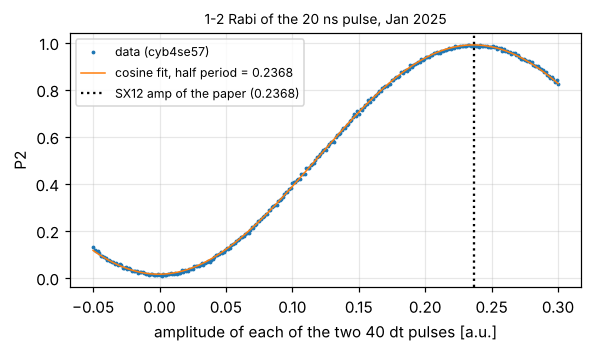

In [3]:
z = np.load(io.data_path(P, "rabi12", "rabi12_amps_-0.05_0.3_brisbane109_pop2.npz"))
A_half, popt, y_fit = fitting.pi_amplitude_from_cosine_fit(z["amp_sweep"], z["pop2"])
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(z["amp_sweep"], z["pop2"], ".", ms=3, label="data (cyb4se57)")
ax.plot(z["amp_sweep"], y_fit, lw=1, label=f"cosine fit, half period = {A_half:.4f}")
ax.axvline(C.PARAMS["brisbane_q109_2025-02"]["sx12"]["amp"], color="k", ls=":", label="SX12 amp of the paper (0.2368)")
ax.set_xlabel("amplitude of each of the two 40 dt pulses [a.u.]"); ax.set_ylabel("P2"); ax.legend(fontsize=8); ax.set_title("1-2 Rabi of the 20 ns pulse, Jan 2025", fontsize=9)
io.save_fig(fig, "12_rabi12_after_correction_pop2")
print(f"the circuit plays the pulse twice, so half a period is the pi/2 amplitude: {A_half:.5f}  (paper: 0.23679; rough-Rabi value before correction: 0.2512)")

## 2. Amplified amplitude error (AAE): the three states of the π/2₁₂ pulse

The rotation-error sequence of notebook 04 — $|1\rangle \to \pi/2_{12} \to (\pi/2_{12}\,\pi/2_{12})^N$, read $p_2$ — was re-run
with the pulse in four states: the rough-calibrated Gaussian (amp 0.2512, *uncorrected*), the same with a DRAG-Y correction only
(`only_dragy`), the amplitude rescaled by $1/(1 + 2\epsilon/\pi)$ without DRAG (`corrected_failed`: the scaling alone does not
help) and rescaled **with** DRAG (`corrected_succeeded`, three repeats). The gate-based model of the paper is a two-level unitary
$U = Z(\delta)\,X(\pi/2 + \epsilon)\,Z(\delta)$ — `qutrit.rotation_error_sequence(a, p, N, mode="pairs")` with $a = \epsilon$,
$p = 2\delta$ in the conventions of notebook 04.

uncorrected pulse: epsilon = 0.0629 rad (4.0 % of pi/2), p = 0.3536  (paper: 0.0629, 0.3537; loss 1.27e-04)


DRAG-Y only:       epsilon = 0.1028 rad, p = 0.0860  (paper: 0.0978, ~0)


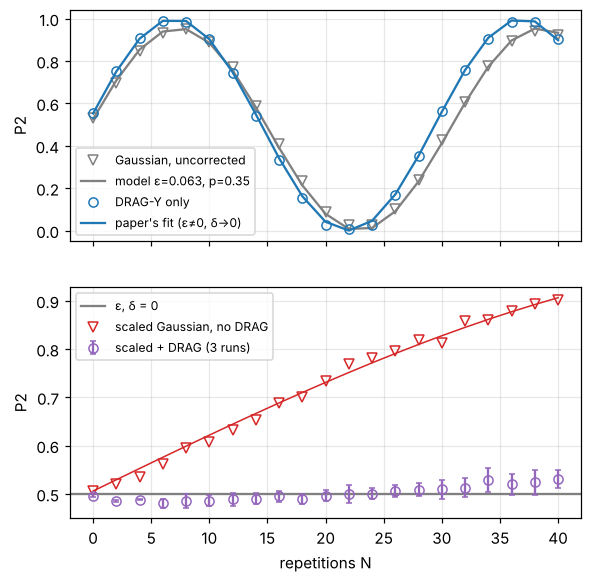

In [4]:
aae = {k: np.load(io.data_path(P, "aae", f"aae_{k}.npz")) for k in
       ["uncorrected", "only_dragy", "only_dragy_fit", "corrected_failed", "corrected_succeeded", "sim_gatebased", "sim_gatebased_onlyepsilon", "sim_corrected_failed"]}
N = aae["uncorrected"]["N"]

def loss(x, data):
    return np.mean((Q.rotation_error_sequence(x[0], x[1], N, mode="pairs")[:, 1] - data) ** 2)

best = min((minimize(loss, [a0, p0], args=(aae["uncorrected"]["pop2"],), method="Nelder-Mead") for a0 in [0.03, 0.08] for p0 in [0.1, 0.4]),
           key=lambda r: r.fun)
eps_fit, p_fit = best.x
print(f"uncorrected pulse: epsilon = {eps_fit:.4f} rad ({eps_fit/(np.pi/2)*100:.1f} % of pi/2), p = {p_fit:.4f}  (paper: 0.0629, 0.3537; loss {best.fun:.2e})")
best_d = min((minimize(loss, [a0, p0], args=(aae["only_dragy"]["pop2"],), method="Nelder-Mead") for a0 in [0.05, 0.1] for p0 in [0.0, 0.3]),
             key=lambda r: r.fun)
print(f"DRAG-Y only:       epsilon = {best_d.x[0]:.4f} rad, p = {best_d.x[1]:.4f}  (paper: 0.0978, ~0)")

fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
ax = axes[0]
ax.plot(N, aae["uncorrected"]["pop2"], "v", mfc="none", color="gray", label="Gaussian, uncorrected")
ax.plot(N, Q.rotation_error_sequence(eps_fit, p_fit, N, mode="pairs")[:, 1], color="gray", label=f"model ε={eps_fit:.3f}, p={p_fit:.2f}")
ax.plot(N, aae["only_dragy"]["pop2"], "o", mfc="none", color="tab:blue", label="DRAG-Y only")
ax.plot(N, aae["only_dragy_fit"]["pop2"], color="tab:blue", label="paper's fit (ε≠0, δ→0)")
ax.set_ylabel("P2"); ax.legend(fontsize=8)
ax = axes[1]
ax.axhline(0.5, color="gray", label="ε, δ = 0")
ax.plot(N, aae["corrected_failed"]["pop2"], "v", mfc="none", color="tab:red", label="scaled Gaussian, no DRAG")
ax.plot(N, aae["sim_corrected_failed"]["pop2"], color="tab:red", lw=1)
m, s = aae["corrected_succeeded"]["pop2s"].mean(0), aae["corrected_succeeded"]["pop2s"].std(0)
ax.errorbar(N, m, s, fmt="o", mfc="none", color="tab:purple", capsize=2, label="scaled + DRAG (3 runs)")
ax.set_xlabel("repetitions N"); ax.set_ylabel("P2"); ax.legend(fontsize=8)
io.save_fig(fig, "12_aae_uncorrected_drag_scaled")

Scaling the amplitude by the ε found on the uncorrected pulse *fails* (red): the phase error δ of the uncorrected Gaussian is
large and correlated with ε, so the fitted ε is not the ε of the DRAG-corrected pulse. Correcting the phase first (DRAG-Y, blue)
makes the N-dependence a clean over-rotation, ε ≈ 0.098 rad, and scaling by *that* lands on $p_2 = 0.5$ for all N (purple).
This is the observation that motivated the DRAPE idea below: the two errors must be learned together.

## 3. Amplified phase error (APE), Gaussian vs DRAG, for n = 1, 3, 5, 7

fringe phases, Gaussian n=1,3,5,7: [0.0913 0.1857 0.2717 0.3561]  DRAG: [-0.0083 -0.0044 -0.0035  0.0031]
stored init_phases          : [-0.0913 -0.1857 -0.2717 -0.3561]            [ 0.0083  0.0044  0.0035 -0.0031]


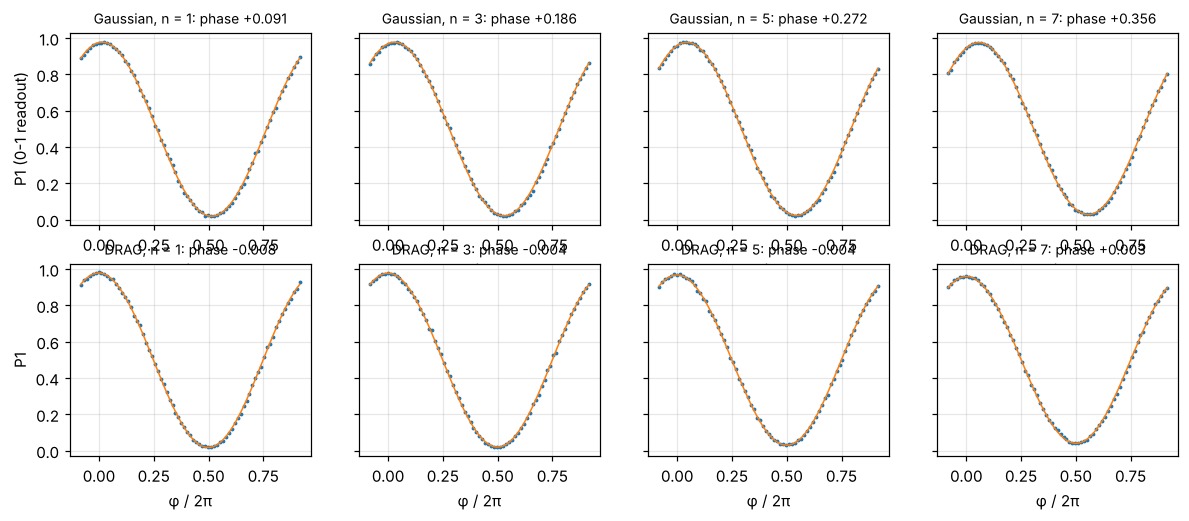

In [5]:
ape = np.load(io.data_path(P, "ape", "ape_data.npz")); phi = ape["angle_swept"]; pops = ape["pe_pops"]   # (8, 75, 3): Gaussian n=1,3,5,7 then DRAG
init = np.load(io.data_path(P, "ape", "init_phases.npz"))["init_phases"]
fig, axes = plt.subplots(2, 4, figsize=(13, 5), sharey=True)
shifts = []
for i in range(8):
    ax = axes[i // 4, i % 4]
    ax.plot(phi / (2 * np.pi), pops[i][:, 0], ".", ms=3)
    popt, _ = curve_fit(lambda x, A, B, ph: A * np.cos(x - ph) + B, phi, pops[i][:, 0], p0=[0.4, 0.5, 0.0])
    shifts.append(popt[2]); ax.plot(phi / (2 * np.pi), popt[0] * np.cos(phi - popt[2]) + popt[1], lw=1)
    ax.set_title(("Gaussian" if i < 4 else "DRAG") + f", n = {2*(i%4)+1}: phase {popt[2]:+.3f}", fontsize=9)
    ax.set_xlabel("φ / 2π")
axes[0, 0].set_ylabel("P1 (0-1 readout)"); axes[1, 0].set_ylabel("P1")
io.save_fig(fig, "12_ape_fringes_gaussian_vs_drag")
shifts = np.array(shifts)
print("fringe phases, Gaussian n=1,3,5,7:", np.round(shifts[:4], 4), " DRAG:", np.round(shifts[4:], 4))
print("stored init_phases          :", np.round(init[:4], 4), "          ", np.round(init[4:], 4))

phase error per pseudo-identity: Gaussian 0.0440 rad/n, DRAG -8.3e-04 rad/n  (notebook 04 / paper: 4.40e-2 and 8.3e-4)


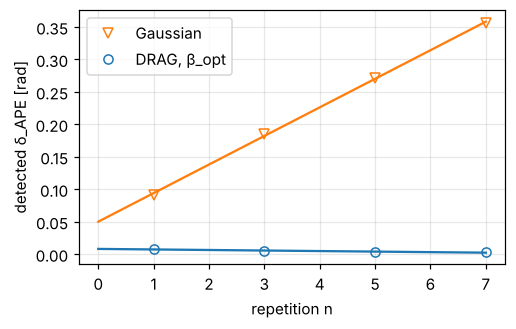

In [6]:
n = np.array([1, 3, 5, 7])
fit_lin = np.load(io.data_path(P, "ape", "fit_init_phases.npz"))
slope_g, _ = np.polyfit(n, np.abs(init[:4]), 1); slope_d, _ = np.polyfit(n, np.abs(init[4:]), 1)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(n, np.abs(init[:4]), "v", mfc="none", color="tab:orange", label="Gaussian"); ax.plot([0, 1, 3, 5, 7], fit_lin["lin1"], color="tab:orange")
ax.plot(n, np.abs(init[4:]), "o", mfc="none", color="tab:blue", label="DRAG, β_opt"); ax.plot([0, 1, 3, 5, 7], fit_lin["lin2"], color="tab:blue")
ax.set_xlabel("repetition n"); ax.set_ylabel("detected δ_APE [rad]"); ax.legend()
io.save_fig(fig, "12_ape_phase_vs_n")
print(f"phase error per pseudo-identity: Gaussian {slope_g:.4f} rad/n, DRAG {slope_d:.1e} rad/n  (notebook 04 / paper: 4.40e-2 and 8.3e-4)")

## 4. DRAPE: DRAG + APE in one sweep, and reading ε and β₀ from it

Fix the final APE phase at $\varphi = \pi/2$, where the fringe is steepest, and sweep the DRAG coefficient β for several
repetition numbers $n = 1, 3, \dots, 11$. $p_2(\beta)$ crosses 0.5 at the β that cancels the phase error, $\beta_0$, and the slope
grows with $n$. The 2026 note shows that the *height* of the curves away from the crossing carries the amplitude error ε:
in closed form, with $A = \cos(\epsilon/2) - \sin(\epsilon/2)$, $B = \cos(\epsilon/2)+\sin(\epsilon/2)$ and $\delta = \xi(\beta-\beta_0)$,
$(U_-U_+)^{2n+1}$ is a Chebyshev-like polynomial in $\cos\theta = \tfrac12[(1+\sin\epsilon) + (1-\sin\epsilon)\cos 2\delta]$
(`docs/drape_unitary_definitions.md`), so one sweep determines $(\epsilon, \beta_0, \xi)$ — the "single experiment" of the title.

beta_0 from the linear fits, n = 1..11: [-0.386 -0.398 -0.397 -0.399 -0.397 -0.401]  mean -0.398
the 2026 note: beta_0 = -0.3714 (normalised units), epsilon_0 = 0.0976, xi = 0.06; notebook 03 (paper): beta = -0.414 in Qiskit units


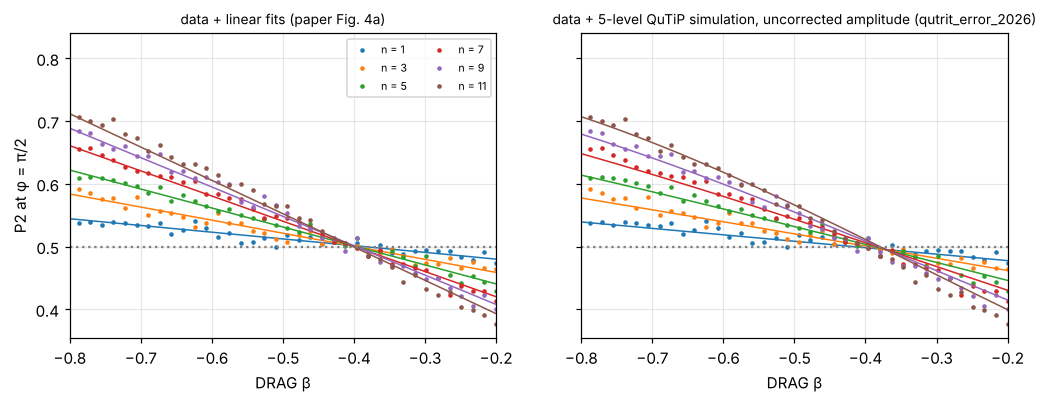

In [7]:
dr = np.load(io.data_path(P, "drag_ape", "drag_ape_data.npz")); beta = dr["beta_swept"]; dp = dr["drape_pops"]; yfit = dr["y_fit_pops"]
sim_unc = np.load(io.data_path(QE, "simu", "drape_simulation_uncorrected_amp.npz"))["arr_0"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
beta0 = []
for i in range(6):
    c = f"C{i}"
    axes[0].plot(beta, dp[i][:, 2], ".", color=c, ms=4, label=f"n = {2*i+1}"); axes[0].plot(beta, yfit[i], color=c, lw=1)
    axes[1].plot(beta, dp[i][:, 2], ".", color=c, ms=4); axes[1].plot(beta, sim_unc[i][:, 2], color=c, lw=1)
    k = np.argmin(np.abs(yfit[i] - 0.5));
    slope = (yfit[i][-1] - yfit[i][0]) / (beta[-1] - beta[0])
    beta0.append(beta[k] - (yfit[i][k] - 0.5) / slope)
for ax in axes:
    ax.axhline(0.5, color="gray", ls=":"); ax.set_xlabel("DRAG β"); ax.set_xlim(-0.8, -0.2)
axes[0].set_ylabel("P2 at φ = π/2"); axes[0].set_title("data + linear fits (paper Fig. 4a)", fontsize=9); axes[0].legend(fontsize=7, ncol=2)
axes[1].set_title("data + 5-level QuTiP simulation, uncorrected amplitude (qutrit_error_2026)", fontsize=9)
io.save_fig(fig, "12_drape_beta_sweep_data_fit_sim")
print("beta_0 from the linear fits, n = 1..11:", np.round(beta0, 3), " mean %.3f" % np.mean(beta0[1:]))
print("the 2026 note: beta_0 = -0.3714 (normalised units), epsilon_0 = 0.0976, xi = 0.06; notebook 03 (paper): beta = -0.414 in Qiskit units")

The `simu/` files are the five-level simulation of the same sweep with the uncorrected (0.2512) and the ε-corrected (0.2365)
amplitude, and `drape_results_fit_various_gamma.npz` is a grid of 25 values of the fractional detuning γ of the 1–2 drive used
to find the one that best reproduces the data (γ ≈ −3.6·10⁻⁴, i.e. a drive 0.1 MHz off the charge-dispersed 1–2 line).
The `extended_`/`zoomed_` files widen and narrow the β range of the same simulation.

residual of the simulation vs data for the 25 trial gammas (index of the best): 8  rss = 1.46e-04


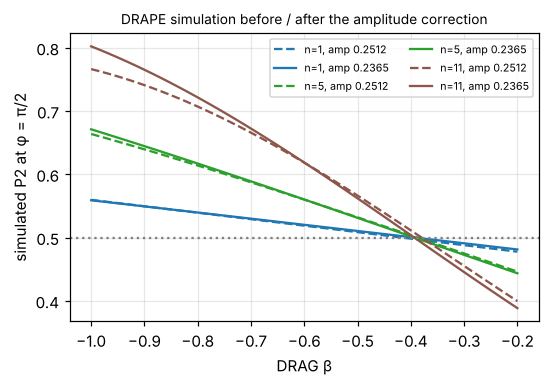

In [8]:
grid = np.load(io.data_path(QE, "drag_and_ape", "drape_results_fit_various_gamma.npz"))["drape_results_fit_various_gamma"]   # (25 gammas, 6 n, 50 beta, 3)
rss = ((grid[:, :, :, 2] - dp[None, :, :, 2]) ** 2).mean(axis=(1, 2))
print("residual of the simulation vs data for the 25 trial gammas (index of the best):", np.argmin(rss), " rss = %.2e" % rss.min())
sim_cor = np.load(io.data_path(QE, "simu", "drape_simulation_corrected_amp.npz"))["arr_0"]
fig, ax = plt.subplots(figsize=(5.5, 3.4))
for i in [0, 2, 5]:
    ax.plot(beta, sim_unc[i][:, 2], "--", color=f"C{i}", label=f"n={2*i+1}, amp 0.2512")
    ax.plot(beta, sim_cor[i][:, 2], "-", color=f"C{i}", label=f"n={2*i+1}, amp 0.2365")
ax.axhline(0.5, color="gray", ls=":"); ax.set_xlabel("DRAG β"); ax.set_ylabel("simulated P2 at φ = π/2"); ax.legend(fontsize=7, ncol=2)
ax.set_title("DRAPE simulation before / after the amplitude correction", fontsize=9)
io.save_fig(fig, "12_drape_simulation_uncorrected_vs_corrected")

With the amplitude corrected the curves for all $n$ cross 0.5 at the same β and are symmetric about it; with the uncorrected
amplitude they are shifted and tilted by ε — which is exactly the handle that lets one sweep measure both errors.

## 5. Qutrit randomized benchmarking with the uncorrected and the corrected pulses (2025)

The 216-element Clifford group of notebook 05 was run again on q109 (Clifford depth 0–800 in steps of 25, 36–40 random seeds per
depth), three times with each pulse set: plain RB, interleaved with the qutrit Hadamard $H_3$, and interleaved with $X_\pi^{(12)}$.
The 2025 analysis used the real part of $\langle Z\rangle = p_0 + \omega p_1 + \omega^2 p_2$ ($\omega = e^{2\pi i/3}$) as the
decaying observable and a bounded fit $A p^m + B$ (`fitting.rb_decay_bounded`); `rb_*.npz` hold the post-selected means and fits,
`pops/*.csv` the per-seed populations and `expectZ/*.csv` the mean $\langle Z\rangle$ of every depth.

 uc: p = 0.98958  r (avg error per Clifford, (1-p)(d-1)/d) = 6.94e-3   e_F (process infidelity, (1-p)(1-1/d^2)) = 9.26 ± 0.46 e-3
  c: p = 0.99482  r (avg error per Clifford, (1-p)(d-1)/d) = 3.45e-3   e_F (process infidelity, (1-p)(1-1/d^2)) = 4.60 ± 0.17 e-3
   H  uc: interleaved gate error = +11.86e-3
   H   c: interleaved gate error = +3.38e-3
pi12  uc: interleaved gate error = +2.16e-3
pi12   c: interleaved gate error = -1.97e-3


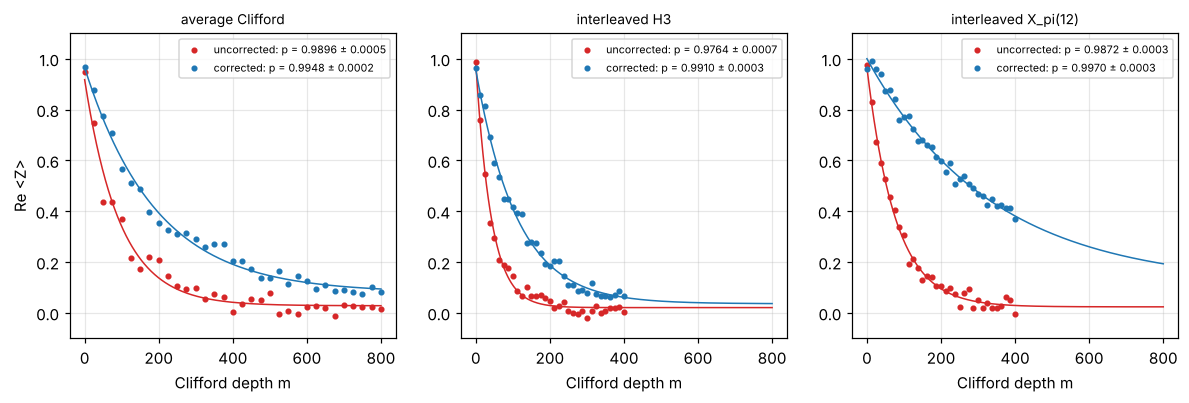

In [9]:
rb = {k: np.load(io.data_path(P, "rb", f"rb_{k}.npz")) for k in ["uc", "c", "H_uc", "H_c", "pi12_uc", "pi12_c"]}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (name, key) in zip(axes, [("average Clifford", ""), ("interleaved H3", "H_"), ("interleaved X_pi(12)", "pi12_")]):
    for cu, col, lab in [("uc", "tab:red", "uncorrected"), ("c", "tab:blue", "corrected")]:
        d = rb[key + cu]
        ax.plot(d["depth_arr"], d["expectZ"], "o", ms=3, color=col, label=f"{lab}: p = {float(d['f_fit']):.4f} ± {float(d['std']):.4f}")
        ax.plot(d["m_fit"], d["fit_vals"], color=col, lw=1)
    ax.set_xlabel("Clifford depth m"); ax.set_title(name, fontsize=9); ax.legend(fontsize=7); ax.set_ylim(-0.1, 1.1)
axes[0].set_ylabel("Re <Z>")
io.save_fig(fig, "12_rb_2025_corrected_vs_uncorrected")

for cu in ["uc", "c"]:
    p = float(rb[cu]["f_fit"]); s = float(rb[cu]["std"])
    print(f"{cu:>3}: p = {p:.5f}  r (avg error per Clifford, (1-p)(d-1)/d) = {fitting.rb_error_per_clifford(p)*1e3:.2f}e-3   "
          f"e_F (process infidelity, (1-p)(1-1/d^2)) = {fitting.rb_process_infidelity(p)*1e3:.2f} ± {fitting.rb_process_infidelity(1 - s)*1e3:.2f} e-3")
for g in ["H", "pi12"]:
    for cu in ["uc", "c"]:
        e = fitting.interleaved_gate_error(float(rb[f"{g}_{cu}"]["f_fit"]), float(rb[cu]["f_fit"]))
        print(f"{g:>4} {cu:>3}: interleaved gate error = {e*1e3:+.2f}e-3")

The corrected pulses halve the error per Clifford (9.3·10⁻³ → 4.6·10⁻³ in process infidelity; 6.9·10⁻³ → 3.5·10⁻³ as $r$) and
cut the $H_3$ error from 1.2 % to 0.34 %. The interleaved $X_\pi^{(12)}$ with corrected pulses gives a *negative* error — the
interleaved decay is slower than the reference, i.e. the gate error is below the resolution of this RB (its statistical error on
$p$ is 3·10⁻⁴), a known limitation of interleaved RB when the interleaved gate is better than the average Clifford.
Compare notebook 06 (ibm_lagos, 2023, 144–160 dt pulses, 2 µs sequences): $r \approx 1.9\,\%$ — ten times worse than the 20 ns
pulses of 2025.

Re-fitting from the per-seed populations shows the pipeline. The npz fits used 20 post-selected seeds (the indices are listed in
`rb_plot.ipynb`); using all seeds gives a slightly different $p$:

corrected RB from all 36 seeds: p = 0.9930 ± 0.0002  (post-selected 20 seeds: 0.9948)


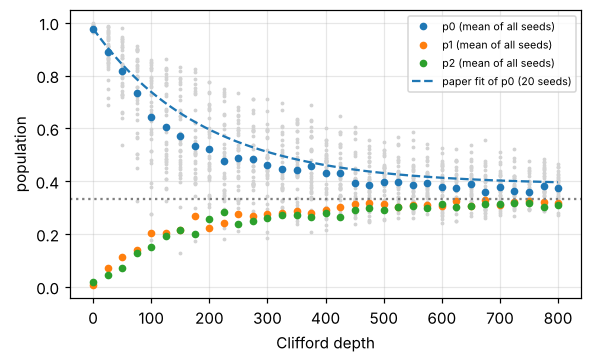

In [10]:
pop_c = np.loadtxt(io.data_path(P, "rb", "pops", "pop_c.csv")); pop_c = pop_c.reshape(pop_c.shape[0], 3, -1)   # (seeds, 3 levels, depths)
depth = rb["c"]["depth_arr"]
z_all = np.real(fitting.expect_z_qutrit(*pop_c.mean(0)))
(A, p, B), p_std = fitting.rb_decay_bounded(depth, z_all)
print(f"corrected RB from all {pop_c.shape[0]} seeds: p = {p:.4f} ± {p_std:.4f}  (post-selected 20 seeds: {float(rb['c']['f_fit']):.4f})")
fig, ax = plt.subplots(figsize=(6, 3.4))
for i in range(pop_c.shape[0]):
    ax.plot(depth, pop_c[i, 0], ".", color="lightgray", ms=3)
for k, lab in enumerate(["p0", "p1", "p2"]):
    ax.plot(depth, pop_c[:, k].mean(0), "o", ms=4, label=lab + " (mean of all seeds)")
ax.plot(rb["c"]["m_fit"], rb["c"]["fit_vals_0"], "--", color="C0", label="paper fit of p0 (20 seeds)")
ax.axhline(1 / 3, color="gray", ls=":"); ax.set_xlabel("Clifford depth"); ax.set_ylabel("population"); ax.legend(fontsize=7)
io.save_fig(fig, "12_rb_2025_populations_all_seeds")

## 6. T₁ cascade and Ramsey of the 1–2 transition, as fitted for the paper's appendix

`master_eqn.ipynb` derived the Lindblad model with the two decay channels $|2\rangle\to|1\rangle$ ($\Gamma_{21}$) and
$|1\rangle\to|0\rangle$ ($\Gamma_{10}$) and fitted the three populations of the $T_1$ measurement of notebook 09 at once; the closed
form is `simulation.three_level_decay`.

Gamma_21 = 0.0065/µs (T = 152.8 µs),  Gamma_10 = 0.0065/µs (T = 152.7 µs)   master_eqn.ipynb: 142.7 µs and 148.8 µs


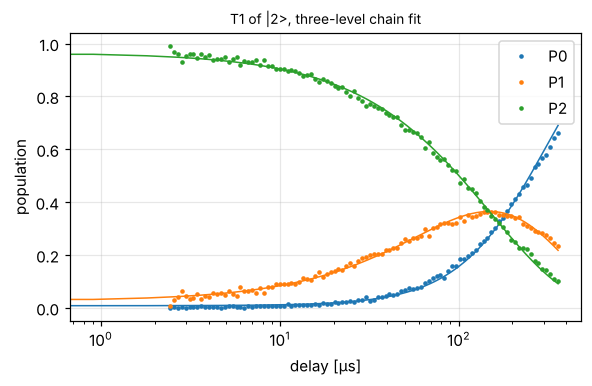

In [11]:
t1 = np.load(io.data_path(P, "t1_measurement", "data_main.npz")); t = t1["delay_time_mu"]
pops3 = np.vstack([t1["pop0"], t1["pop1"], t1["pop2"]]).T
def model(tt, g21, g10, p2_0, p1_0):
    return sim.three_level_decay(tt, g21, g10, p2_0=p2_0, p1_0=p1_0).ravel()
popt, pcov = curve_fit(model, t, pops3.ravel(), p0=[0.007, 0.007, 0.98, 0.01])
g21, g10 = popt[:2]
print(f"Gamma_21 = {g21:.4f}/µs (T = {1/g21:.1f} µs),  Gamma_10 = {g10:.4f}/µs (T = {1/g10:.1f} µs)   master_eqn.ipynb: 142.7 µs and 148.8 µs")
fig, ax = plt.subplots(figsize=(6, 3.4))
tt = np.linspace(0, t.max(), 400); mod = sim.three_level_decay(tt, g21, g10, p2_0=popt[2], p1_0=popt[3])
for k in range(3):
    ax.plot(t, pops3[:, k], ".", ms=4, color=f"C{k}", label=f"P{k}"); ax.plot(tt, mod[:, k], color=f"C{k}", lw=1)
ax.set_xscale("log"); ax.set_xlabel("delay [µs]"); ax.set_ylabel("population"); ax.legend(); ax.set_title("T1 of |2>, three-level chain fit", fontsize=9)
io.save_fig(fig, "12_t1_cascade_fit_paper")

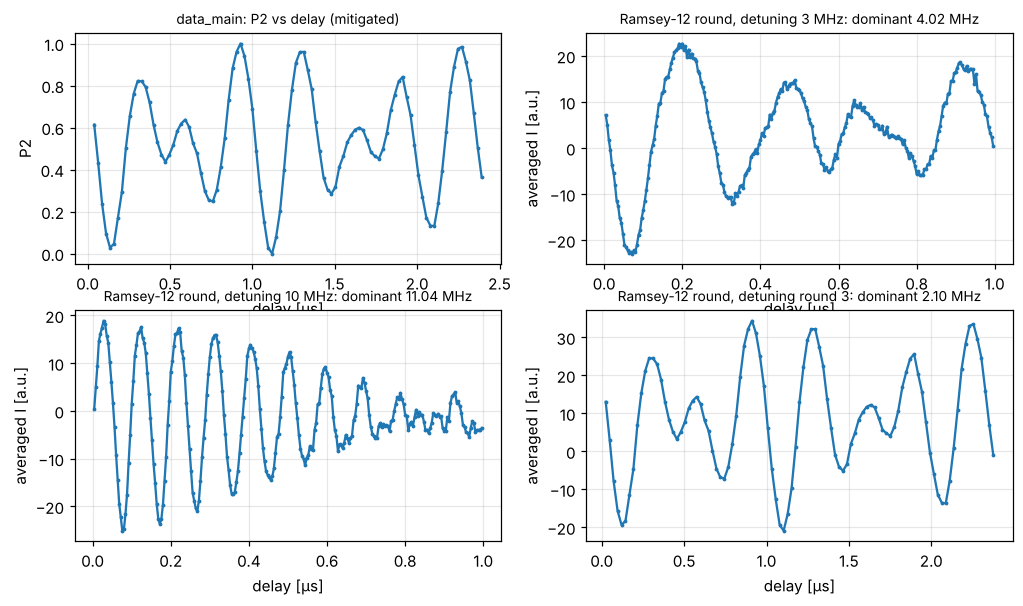

In [12]:
rm = np.load(io.data_path(P, "ramsey_measurement", "data_main.npz"))
rounds = [np.load(io.data_path(P, "ramsey_measurement", f"round{r}.npy")) for r in [1, 2, 3]]
delays = [np.arange(8, 2000, 8) * C.dt * 1e6, np.arange(8, 2000, 8) * C.dt * 1e6, np.arange(48, 4800, 48) * C.dt * 1e6]
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
axes[0, 0].plot(rm["delayramsey_time_mu"], rm["pop2"], ".-", ms=3); axes[0, 0].set_title("data_main: P2 vs delay (mitigated)", fontsize=9)
axes[0, 0].set_xlabel("delay [µs]"); axes[0, 0].set_ylabel("P2")
for ax, r, d, det in zip([axes[0, 1], axes[1, 0], axes[1, 1]], rounds, delays, ["3 MHz", "10 MHz", "round 3"]):
    ax.plot(d, r, ".-", ms=3); ax.set_xlabel("delay [µs]"); ax.set_ylabel("averaged I [a.u.]")
    f, _, _ = fitting.dominant_frequency(d, r - r.mean())
    ax.set_title(f"Ramsey-12 round, detuning {det}: dominant {f:.2f} MHz", fontsize=9)
io.save_fig(fig, "12_ramsey_rounds_paper")

The rounds show the beating of the charge-dispersion doublet of the 1–2 transition discussed in notebook 09 (two or three
frequencies ≈ 0.3 MHz apart in the 3-frequency fits of `master_eqn.ipynb`). The three Ramsey jobs of 28 Jan 2025 — 0.1 MHz
detuning in two delay windows (8–800 and 800–1600 dt) and 0.5 MHz (8–800 dt), 5000 shots per delay — are earlier attempts of the
same measurement; their shots are in part 2 of the `v1.0-data` release and are plotted here if present.

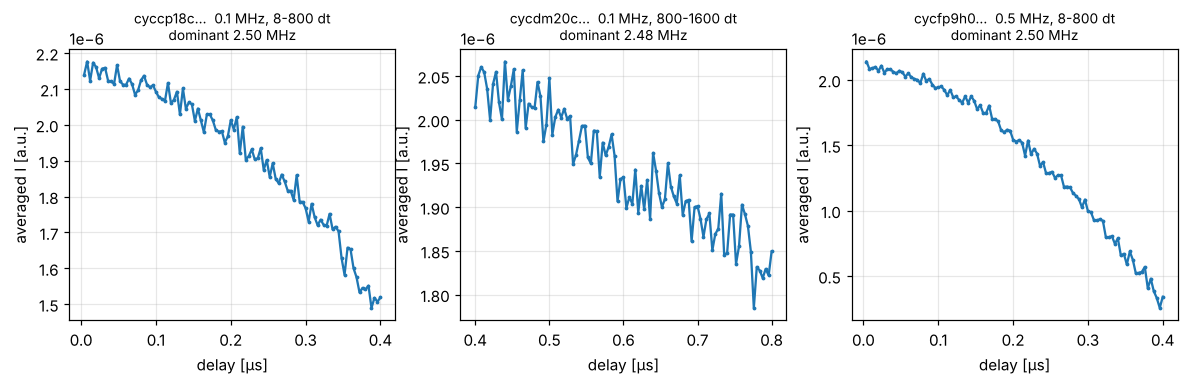

In [13]:
jobs = {"cyccp18cw2k0008kksc0": "0.1 MHz, 8-800 dt", "cycdm20cw2k0008kky2g": "0.1 MHz, 800-1600 dt", "cycfp9h01rbg008jyq00": "0.5 MHz, 8-800 dt"}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, (job, lab) in zip(axes, jobs.items()):
    folder = io.data_path("pending_2025", "characterization", "ramsey", "data", job)
    prm = io.load_params(folder)
    d_dt = np.arange(prm["start_delay"], prm["end_delay"] + prm["granularity"], prm["granularity"])
    if (folder / "iq_data.npy").exists():
        iq, _ = io.load_job(folder); sig = np.real(iq.mean(axis=1)) * C.scale_factor
        d_us = d_dt[: len(sig)] * C.dt * 1e6
        ax.plot(d_us, sig, ".-", ms=3)
        f, _, _ = fitting.dominant_frequency(d_us, sig - sig.mean()); ax.set_title(f"{job[:8]}…  {lab}\ndominant {f:.2f} MHz", fontsize=9)
    else:
        ax.text(0.5, 0.5, "iq_data.npy not downloaded\n(release v1.0-data, part 2)", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{job[:8]}…  {lab}", fontsize=9)
    ax.set_xlabel("delay [µs]"); ax.set_ylabel("averaged I [a.u.]")
io.save_fig(fig, "12_ramsey_jobs_2025-01-28")

## 7. The frame phases from randomised circuits, one more time

`rpc_figure5` is the summary the paper used for its appendix figure on the phase advance (compare notebook 07): the two frame
phases fitted on randomised phase circuits of growing length converge to constant values.

alpha01 = -0.925 rad, alpha12 = +2.703 rad;  notebook 08 (pseudo-identity Ramsey): |beta| = 0.928, pi - |alpha| = 2.683


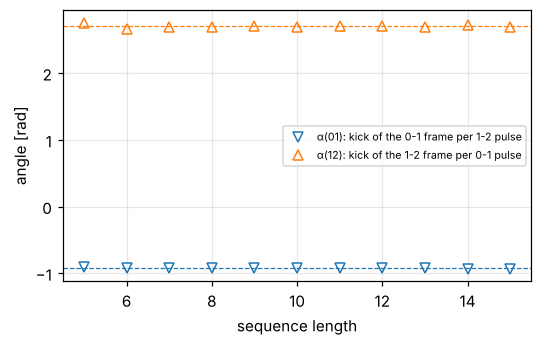

In [14]:
rpc = json.load(open(io.data_path(P, "phase_advance", "rpc_figure5.json")))
L = np.array(rpc["sequence length"]); a01 = np.array(rpc["alpha01"]) - 2 * np.pi; a12 = np.array(rpc["alpha12"])
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(L, a01, "v", mfc="none", color="tab:blue", label="α(01): kick of the 0-1 frame per 1-2 pulse")
ax.plot(L, a12, "^", mfc="none", color="tab:orange", label="α(12): kick of the 1-2 frame per 0-1 pulse")
ax.axhline(a01[3:].mean(), color="tab:blue", ls="--", lw=0.8); ax.axhline(a12[3:].mean(), color="tab:orange", ls="--", lw=0.8)
ax.set_xlabel("sequence length"); ax.set_ylabel("angle [rad]"); ax.legend(fontsize=7)
io.save_fig(fig, "12_rpc_frame_phases_vs_length")
print(f"alpha01 = {a01[3:].mean():+.3f} rad, alpha12 = {a12[3:].mean():+.3f} rad;  notebook 08 (pseudo-identity Ramsey): |beta| = 0.928, pi - |alpha| = {np.pi-0.459:.3f}")

## 8. The 2023 intermezzo: the QOC group on `ibm_oslo`

Between the Lab (2022) and the Shop (Dec 2023) the group ran under the name "QOC" (quantum optimal control): a project proposal
(`docs/qoc_proposal_2023.docx`), journal-club slides (`docs/meetings/`), a small reading list on optimal control and qudit RB
(`literature/`), and one calibration session on `ibm_oslo` q0 on 5 Feb 2023 whose parameter files are kept in `data/qoc_2023/`:

q0_zo160_ot160/zo.json: {'x_amp': 0.17300039603239967, 'sx_amp': 0.08712462224930756, 'dur': 160, 'beta': 0.21469611947135928}
q0_zo160_ot176/zo.json: {'x_amp': 0.17300039603239967, 'sx_amp': 0.08712462224930756, 'dur': 160, 'beta': 0.21469611947135928}
q0_zo160_ot192/zo.json: {'x_amp': 0.17300039603239967, 'sx_amp': 0.08712462224930756, 'dur': 160, 'beta': 0.21469611947135928}
q0_zo160_ot208/ot.json: {'x_amp': 0.10702239483390295, 'sx_amp': None, 'dur': 208, 'beta': 0}

'zo' = the 0-1 pulse (zero-one), 'ot' = the 1-2 pulse (one-two); the folder name gives their durations in dt.


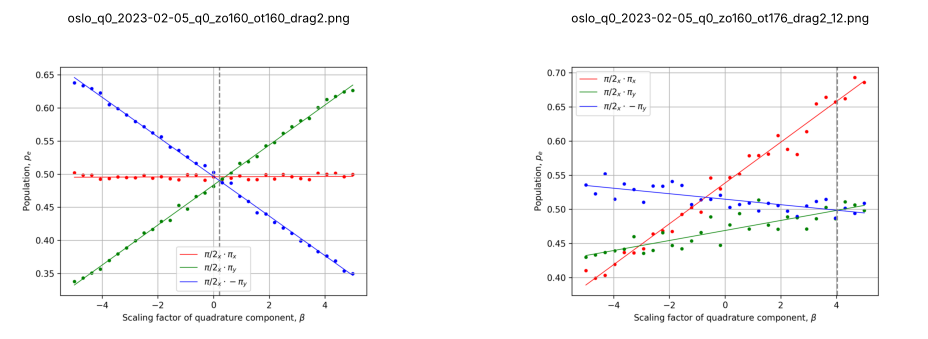

In [15]:
for sub in ["q0_zo160_ot160", "q0_zo160_ot176", "q0_zo160_ot192", "q0_zo160_ot208"]:
    for f in sorted(io.data_path("qoc_2023", "ibm_oslo_q0_2023-02-05", sub).glob("*.json")):
        print(f"{sub}/{f.name}: {json.load(open(f))}")
print("\n'zo' = the 0-1 pulse (zero-one), 'ot' = the 1-2 pulse (one-two); the folder name gives their durations in dt.")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, f in zip(axes, ["oslo_q0_2023-02-05_q0_zo160_ot160_drag2.png", "oslo_q0_2023-02-05_q0_zo160_ot176_drag2_12.png"]):
    ax.imshow(plt.imread(io.fig_path("qoc_2023", f))); ax.axis("off"); ax.set_title(f, fontsize=8)
plt.show()

## 9. Where this leaves the shop

| quantity | 2023 (`ibm_lagos`, 144–160 dt) | 2025 uncorrected 20 ns | 2025 corrected 20 ns |
|---|---|---|---|
| RB decay $p$ | ≈ 0.97 | 0.9896 ± 0.0005 | 0.9948 ± 0.0002 |
| error per Clifford $r = \tfrac23(1-p)$ | ≈ 1.9 % | 0.69 % | 0.35 % |
| $H_3$ interleaved error | 2.4 % | 1.19 % | 0.34 % |
| over-rotation ε of π/2₁₂ | — | 0.063 rad (with δ) / 0.098 rad (δ removed) | ≈ 0 |
| phase error per pseudo-identity | — | 4.4·10⁻² rad | 8·10⁻⁴ rad |

and the 2026 note turns the DRAPE sweep into a one-shot calibration of both errors: $(\epsilon_0, \beta_0, \xi) = (0.098, -0.371, 0.06)$
from a single β sweep at $\varphi = \pi/2$. The bachelor thesis (`docs/thesis_2024_…pdf`) tells the 2022–24 part of the story in
prose; the headline there — a 60 % error-rate reduction of the elementary rotation and $F = 98.9\,\%$ for the qutrit Cliffords —
is the 2024 version of the table above.